In [1]:
!pip install rapidfuzz

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
df = pd.read_csv('C:\project_4\data\processed\Contracts_Clean.csv', low_memory=False)
print("Shape:", df.shape)
print()
print("Null values per column:")
print(df.isna().sum())

Shape: (111887, 13)

Null values per column:
contract_transaction_unique_key        0
award_id_piid                          0
recipient_name                         0
awarding_agency_name                   0
awarding_sub_agency_name               0
product_or_service_code_description    0
naics_description                      2
action_date                            0
federal_action_obligation              0
total_dollars_obligated                0
extent_competed                        0
type_of_contract_pricing               0
award_type                             0
dtype: int64


Good news on data quality - pretty much zero missing values across the board. The only real gap is naics_description, and that's just 2 rows out of 111,887, so nothing to worry about there. Whatever cleanup work is ahead, it's not because the source data is a mess.

In [3]:
print("Total rows:", len(df))
print("Unique award_id_piid values:", df['award_id_piid'].nunique())
print()
print("Award IDs appearing more than once (contracts with modifications):")
print(df['award_id_piid'].value_counts().head(10))

Total rows: 111887
Unique award_id_piid values: 88099

Award IDs appearing more than once (contracts with modifications):
award_id_piid
36C10F23C0007    37
36C10F20C0025    31
36C77023F0041    25
36C10F21C0009    24
36C10F18C3377    23
VA101F16C0025    23
36C10F22C0016    21
36C10A20F0309    20
36C25623F0128    19
36C10B22F0089    19
Name: count, dtype: int64


At first glance, having only 88,099 unique award IDs across 111,887 transactions looks like duplicate data. It isn't. Government contracts get modified over time - extended, amended, adjusted in value - and each modification shows up as its own row tied to the same base award ID. The contract with 37 transactions isn't an error, it's just a contract that's been amended 37 times over the fiscal year. Worth knowing before assuming anything's broken.

In [4]:
import re
df['name_normalized'] = (df['recipient_name'].str.upper()
                          .str.replace(r'[.,]', '', regex=True)
                          .str.replace(r'\s+(INC|CORP|CORPORATION|LLC|LTD|CO)\.?$', '', regex=True)
                          .str.strip())

print("Raw unique vendor names:", df['recipient_name'].nunique())
print("Normalized unique vendor names:", df['name_normalized'].nunique())

Raw unique vendor names: 12010
Normalized unique vendor names: 11879


Just fixing case, punctuation, and stripping common suffixes like "Inc" or "Corp" already collapses a chunk of the duplicate vendor names. This is the low-hanging fruit - the harder duplicates (typos, abbreviations, inconsistent formatting) need something smarter than string replacement, which is what the fuzzy matching below is for.

In [5]:
from rapidfuzz import fuzz
from collections import defaultdict

unique_names = df['name_normalized'].dropna().unique()
print("Total unique normalized names to compare:", len(unique_names))

blocks = defaultdict(list)
for name in unique_names:
    key = name[:4]
    blocks[key].append(name)

candidates = []
for key, names in blocks.items():
    if len(names) > 1:
        for i in range(len(names)):
            for j in range(i+1, len(names)):
                score = fuzz.ratio(names[i], names[j])
                if 85 <= score < 100:
                    candidates.append({'name_a': names[i], 'name_b': names[j], 'similarity_score': round(score,2)})

candidates_df = pd.DataFrame(candidates).sort_values('similarity_score', ascending=False)
print("Candidate duplicate pairs found:", len(candidates_df))
candidates_df.head(20)

Total unique normalized names to compare: 11879
Candidate duplicate pairs found: 225


,name_a,name_b,similarity_score
36,ADVANCE PROSTHETICS AND ORTHOTICS,ADVANCED PROSTHETICS AND ORTHOTICS,98.51
55,AMERICAN VETERANS SERVICES,AMERICAN VETERAN SERVICES,98.04
18,VETERANS FIRST HEALTHCARE,VETERANS FIRST HEALTH CARE,98.04
144,WESTCOAST BRACE & LIMB,WEST COAST BRACE & LIMB,97.78
194,TURN-KEY TECHNOLOGIES,TURNKEY TECHNOLOGIES,97.56
191,MARQUIS COMPANIES II,MARQUIS COMPANIES I,97.44
22,HANGER PROSTHETICS & ORTHOTICS WEST,HANGER PROSTHETICS & ORTHOTICS EAST,97.14
17,VETERANS ELECTRIC,VETERAN ELECTRIC,96.97
120,SOUTHEAST LOUISIANA VETERANS HOME,SOUTHWEST LOUISIANA VETERANS HOME,96.97
222,WINNIE-STOWELL HOSPITAL DISTRICT,WINNIE STOWELL HOSPITAL DISTRICT,96.88


This finds every pair of vendor names that are suspiciously similar (85%+ match) without actually being identical. The temptation here is to just merge anything above the threshold and call it done. That's a mistake. A high similarity score just means the text looks alike - it says nothing about whether it's actually the same company. That's why every one of these 225 pairs gets reviewed by hand before anything gets merged (see the next few cells).

In [6]:
import os
os.makedirs('C:/project_4/data/processed/vendor_cleaning', exist_ok=True)

candidates_df.to_csv('C:/project_4/data/processed/vendor_cleaning/Vendor_Match_Candidates.csv', index=False)
print("Saved candidates file")

Saved candidates file


In [7]:
decisions = pd.read_csv('C:/project_4/data/processed/vendor_cleaning/Vendor_Match_Candidates_Flagged.csv')
print(decisions['reviewer_decision'].value_counts())

reviewer_decision
KEEP_SEPARATE    171
MERGE             54
Name: count, dtype: int64


Out of 225 flagged pairs, the review came back with far more KEEP_SEPARATE decisions than MERGE. That's expected, and honestly a good sign - it means the review process is catching real distinctions (different regions, different specialties, different legal entities) that a similarity score alone can't see. A couple of genuinely tricky ones came up during this pass - "Northwestern University" vs. "Northeastern University" scored over 95% similar despite being completely different schools, and "Advantage Prosthetics & Orthotics" almost got folded into an unrelated "Advanced Prosthetics" vendor group before catching it on a second look.

In [8]:
merges = decisions[decisions['reviewer_decision'] == 'MERGE']
print("Confirmed merge pairs:", len(merges))

parent = {}
def find(x):
    while parent.get(x, x) != x:
        parent[x] = parent.get(parent[x], parent[x])
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for name in unique_names:
    parent.setdefault(name, name)

for _, row in merges.iterrows():
    a, b = row['name_a'], row['name_b']
    if a in parent and b in parent:
        union(a, b)

df['group_root'] = df['name_normalized'].map(lambda n: find(n) if n in parent else n)
print("Final distinct vendor groups:", df['group_root'].nunique())

Confirmed merge pairs: 54
Final distinct vendor groups: 11828


This step uses union-find instead of merging pairs one at a time, because duplicates don't always come in neat pairs - sometimes vendor A matches B, and B separately matches C, which means A, B, and C are all really the same vendor even if A and C were never directly compared. Skipping this step would leave some duplicates only half-merged.

In [9]:
freq = df.groupby(['group_root', 'recipient_name']).size().reset_index(name='txn_count')
canonical = freq.sort_values('txn_count', ascending=False).drop_duplicates('group_root').set_index('group_root')['recipient_name']

groups_sorted = sorted(canonical.index.tolist())
vendor_id_map = {root: f'V{idx+1:05d}' for idx, root in enumerate(groups_sorted)}

raw_names = df[['recipient_name', 'group_root']].drop_duplicates()
raw_names['canonical_vendor_name'] = raw_names['group_root'].map(canonical)
raw_names['vendor_id'] = raw_names['group_root'].map(vendor_id_map)
crosswalk = raw_names[['recipient_name', 'canonical_vendor_name', 'vendor_id']].sort_values('vendor_id')

crosswalk.to_csv('C:/project_4/data/processed/vendor_cleaning/Vendor_Master_Crosswalk.csv', index=False)
print("Total raw vendor names:", len(crosswalk))
print("Total distinct canonical vendors:", crosswalk['vendor_id'].nunique())

Total raw vendor names: 12010
Total distinct canonical vendors: 11828


After all the cleaning - normalization, fuzzy matching, manual review, chain-merging - 12,010 raw vendor name spellings come down to 11,828 real, distinct vendors. That's the number everything downstream (the SQL views, the Excel workbook, the dashboard) is built on.

In [10]:
print("Total transaction rows:", len(df))
print("Unique award_id_piid values:", df['award_id_piid'].nunique())
print()
print("Top 10 award IDs with the most transactions (likely heavily modified contracts):")
print(df['award_id_piid'].value_counts().head(10))

Total transaction rows: 111887
Unique award_id_piid values: 88099

Top 10 award IDs with the most transactions (likely heavily modified contracts):
award_id_piid
36C10F23C0007    37
36C10F20C0025    31
36C77023F0041    25
36C10F21C0009    24
36C10F18C3377    23
VA101F16C0025    23
36C10F22C0016    21
36C10A20F0309    20
36C25623F0128    19
36C10B22F0089    19
Name: count, dtype: int64


Re-running the award ID check after cleaning confirms nothing about the modification pattern changed - this was purely a vendor-name issue, not something that affected how contracts and their amendments relate to each other.

In [11]:
import os
os.makedirs('C:/project_4/python/charts', exist_ok=True)

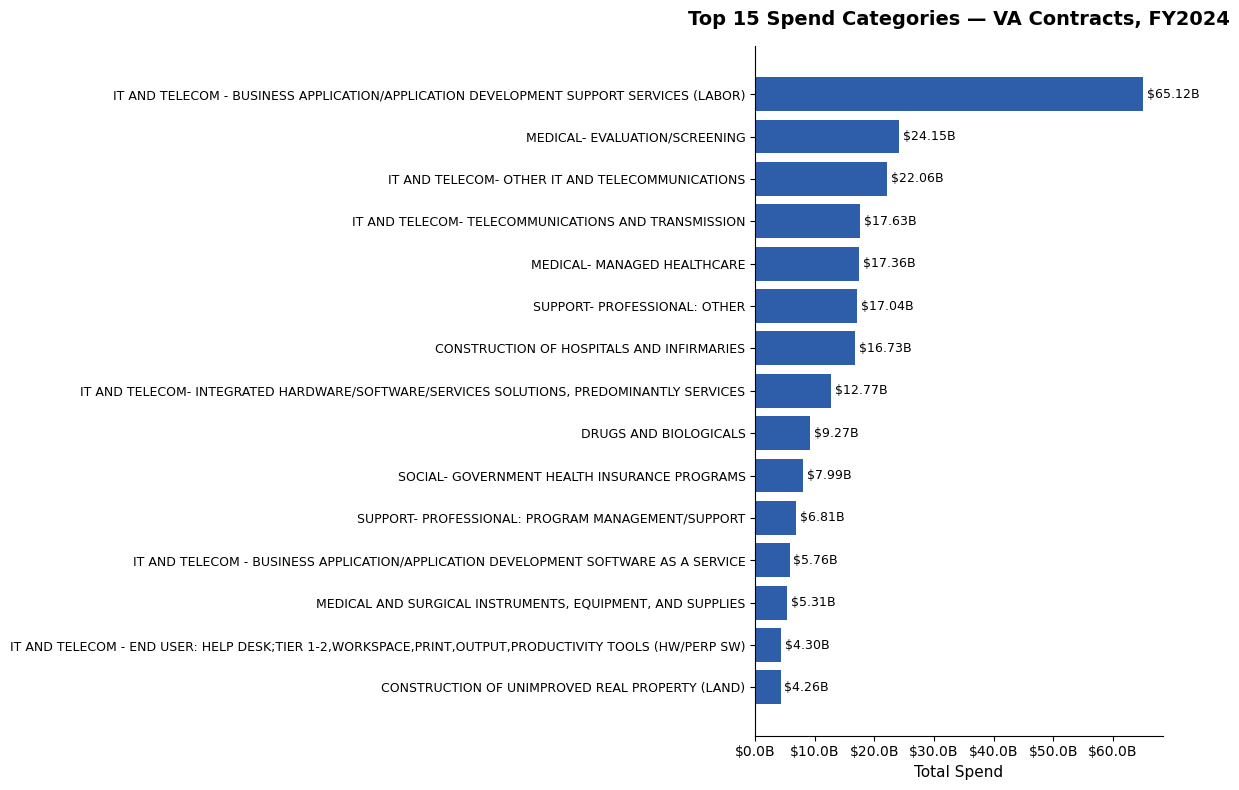

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

category_spend = df.groupby('product_or_service_code_description')['total_dollars_obligated'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(category_spend.index, category_spend.values, color='#2E5EAA')
ax.invert_yaxis()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

for bar in bars:
    width = bar.get_width()
    ax.text(width + (category_spend.max() * 0.01), bar.get_y() + bar.get_height()/2,
             f'${width/1e9:.2f}B', va='center', fontsize=9)

ax.set_xlabel('Total Spend', fontsize=11)
ax.set_ylabel('')
ax.set_title('Top 15 Spend Categories — VA Contracts, FY2024', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('C:/project_4/python/charts/top15_categories_spend.png', dpi=200, bbox_inches='tight')
plt.show()

IT and Telecom - specifically application development support - is the single biggest spend category by a wide margin, sitting at roughly 20% of total spend on its own. Medical evaluation and screening services come in a distant second. For a Veterans Affairs contract dataset, this makes sense - a lot of VA's procurement footprint is systems and software work, not just medical supplies.

Top 10 vendors account for 46.2% of total spend


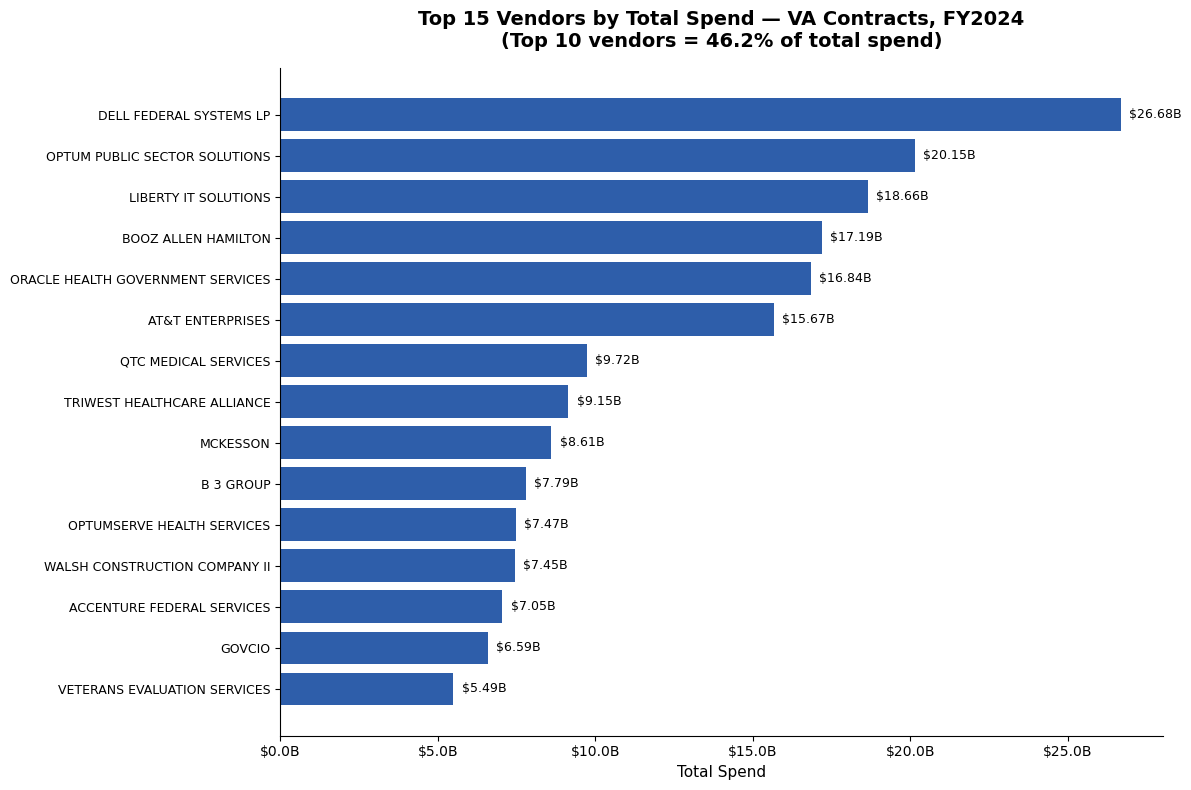

In [13]:
category_spend_col = 'canonical_vendor_name' if 'canonical_vendor_name' in df.columns else 'group_root'
vendor_spend = df.groupby(category_spend_col)['total_dollars_obligated'].sum().sort_values(ascending=False)

top10_share = vendor_spend.head(10).sum() / vendor_spend.sum() * 100
print(f"Top 10 vendors account for {top10_share:.1f}% of total spend")

top15 = vendor_spend.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top15.index, top15.values, color='#2E5EAA')
ax.invert_yaxis()

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

for bar in bars:
    width = bar.get_width()
    ax.text(width + (top15.max() * 0.01), bar.get_y() + bar.get_height()/2,
             f'${width/1e9:.2f}B', va='center', fontsize=9)

ax.set_xlabel('Total Spend', fontsize=11)
ax.set_ylabel('')
ax.set_title(f'Top 15 Vendors by Total Spend — VA Contracts, FY2024\n(Top 10 vendors = {top10_share:.1f}% of total spend)', 
             fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('C:/project_4/python/charts/top15_vendors_spend.png', dpi=200, bbox_inches='tight')
plt.show()

Ten vendors - out of 11,828 - account for 46.2% of all the money spent. That's a meaningful concentration. It's not necessarily a problem (some of these are large, established contractors like Dell Federal Systems and Booz Allen Hamilton, where that scale makes sense), but it's exactly the kind of number a procurement team would want visibility into when planning vendor risk management or negotiating leverage.

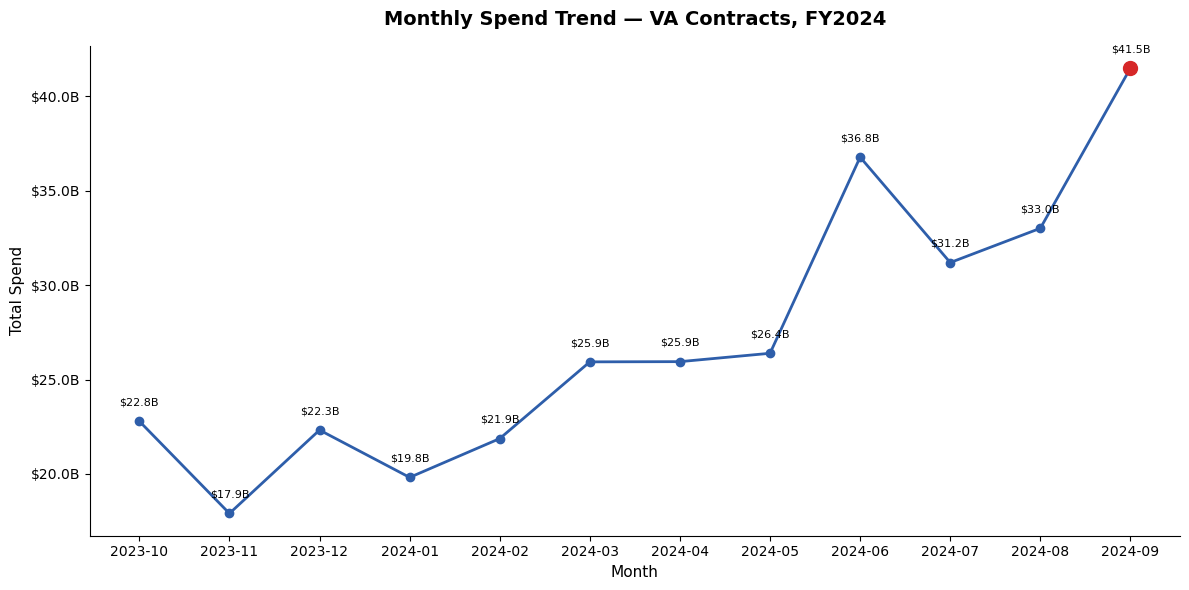

In [14]:
df['action_date'] = pd.to_datetime(df['action_date'])
monthly_spend = df.groupby(df['action_date'].dt.to_period('M'))['total_dollars_obligated'].sum()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_spend.index.astype(str), monthly_spend.values, 
        marker='o', markersize=6, linewidth=2, color='#2E5EAA')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'${y/1e9:.1f}B'))

for i, val in enumerate(monthly_spend.values):
    ax.text(i, val + (monthly_spend.max() * 0.02), f'${val/1e9:.1f}B', 
            ha='center', fontsize=8)

max_idx = monthly_spend.values.argmax()
ax.scatter(max_idx, monthly_spend.values[max_idx], color='#D62728', s=100, zorder=5)

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Spend', fontsize=11)
ax.set_title('Monthly Spend Trend — VA Contracts, FY2024', fontsize=14, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('C:/project_4/python/charts/monthly_spend_trend.png', dpi=200, bbox_inches='tight')
plt.show()

Spend climbs steadily through the year and then jumps sharply in September - the last month of the federal fiscal year. This lines up with a well-documented pattern in government spending: agencies tend to use up remaining budget before it expires rather than let it go unspent. It's not a data quality issue, it's a real, expected behavior worth calling out rather than treating as an anomaly.

In [15]:
vendor_txn_count = df.groupby('group_root').size().sort_values(ascending=False)
one_time_vendors = (vendor_txn_count == 1).sum()
print(f"Vendors with only 1 transaction (long tail): {one_time_vendors} out of {len(vendor_txn_count)} total vendors")
print(f"That's {one_time_vendors/len(vendor_txn_count)*100:.1f}% of all vendors")

Vendors with only 1 transaction (long tail): 4356 out of 11828 total vendors
That's 36.8% of all vendors


More than a third of all vendors - 4,356 out of 11,828 - only ever appear in a single transaction. That's a lot of one-off vendor relationships sitting alongside the handful of vendors that dominate spend. This is the kind of pattern a procurement team would look at and ask: how many of these one-time purchases could have gone through an existing preferred vendor instead? That's where tail-spend consolidation opportunities usually hide.